# 03 - Quantum algorithms

Three algorithms that show quantum advantage clearly. The common thread is interference: wrong answers get amplitude cancellation, right answers get constructive amplification. The quantum speedup doesnt come from parallelism in the naive sense - measuring a superposition still gives one outcome. The speedup comes from engineering the amplitudes before measurement so the right answer has high probability.

- Deutsch-Jozsa: exponential speedup but artificial problem
- Grover: quadratic speedup, general unstructured search
- QFT + QPE: exponential speedup, the core of Shor

By now I have a reasonable grip on basic qiskit, so Im going to focus more on getting the circuits right than explaining each qiskit call.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector

import warnings
warnings.filterwarnings('ignore')

sim = AerSimulator()

## Deutsch-Jozsa

The problem: given a black-box f: {0,1}^n -> {0,1}, promised to be either constant or balanced, determine which. Classically needs O(2^n) queries worst case. Quantum: one query always.

The oracle acts as U_f|x>|y> = |x>|y xor f(x)>. With the output qubit initialised in |-> = (|0>-|1>)/sqrt(2), this produces a phase kickback: |x>|-> -> (-1)^{f(x)} |x>|->. The |-> on the ancilla is unchanged - only the input register picks up the phase.

After applying H^n on the input, measuring all zeros means constant, anything else means balanced. One shot, no ambiguity.

In [2]:
def dj_oracle(n, type='balanced'):
    qc = QuantumCircuit(n+1)
    if type == 'constant_1':
        qc.x(n)
    elif type == 'balanced':
        # simple choice: XOR with first n//2 input bits
        for q in range(n // 2):
            qc.cx(q, n)
    return qc

def deutsch_jozsa(n, oracle_type):
    oracle = dj_oracle(n, oracle_type)
    qc = QuantumCircuit(n+1, n)

    qc.x(n); qc.h(n)        # ancilla in |->
    qc.h(range(n))           # uniform superposition on input
    qc.barrier()
    qc.compose(oracle, inplace=True)
    qc.barrier()
    qc.h(range(n))
    qc.measure(range(n), range(n))
    return qc

for otype in ['constant_0', 'constant_1', 'balanced']:
    counts = sim.run(deutsch_jozsa(4, otype), shots=64).result().get_counts()
    verdict = 'constant' if list(counts.keys()) == ['0000'] else 'balanced'
    print(f'{otype:15s} -> {verdict}')

constant_0      -> constant
constant_1      -> constant
balanced        -> balanced


## Grover search

Find a marked element x* in a database of N = 2^n items. Classical: O(N) average. Quantum: O(sqrt(N)).

The algorithm alternates two reflections:
- Oracle: phase flip on the marked state, |x> -> -|x> for x = x*
- Diffuser: reflection about the uniform superposition |s> = H^n|0>

Two reflections compose to a rotation by 2*arcsin(1/sqrt(N)) in the 2D subspace spanned by |x*> and its orthogonal complement in |s>. Starting from |s> and rotating toward |x*>, the optimal number of steps is roughly pi/4 * sqrt(N).

The probability oscillates - you can overshoot - so the iteration count matters.

In [3]:
def grover_oracle(n, target):
    qc = QuantumCircuit(n)
    # flip qubits where target bit is 0
    for i, bit in enumerate(format(target, f'0{n}b')[::-1]):
        if bit == '0': qc.x(i)
    # multi-controlled Z via H-MCX-H
    qc.h(n-1)
    qc.mcx(list(range(n-1)), n-1)
    qc.h(n-1)
    for i, bit in enumerate(format(target, f'0{n}b')[::-1]):
        if bit == '0': qc.x(i)
    return qc

def grover_diffuser(n):
    qc = QuantumCircuit(n)
    qc.h(range(n))
    qc.x(range(n))
    qc.h(n-1)
    qc.mcx(list(range(n-1)), n-1)
    qc.h(n-1)
    qc.x(range(n))
    qc.h(range(n))
    return qc

def grover(n, target, k=None):
    if k is None:
        k = int(np.round(np.pi / 4 * np.sqrt(2**n)))
    qc = QuantumCircuit(n, n)
    qc.h(range(n))
    for _ in range(k):
        qc.compose(grover_oracle(n, target), inplace=True)
        qc.compose(grover_diffuser(n), inplace=True)
    qc.measure(range(n), range(n))
    return qc

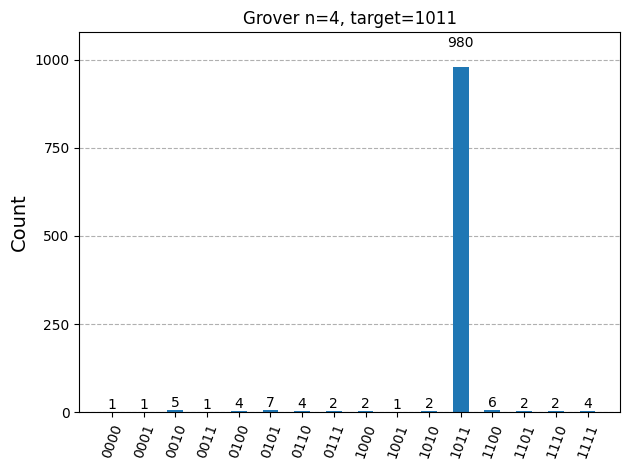

In [4]:
n, target = 4, 11
qc = grover(n, target)
counts = sim.run(qc, shots=1024).result().get_counts()
plot_histogram(counts, title=f'Grover n=4, target={format(target,"04b")}')

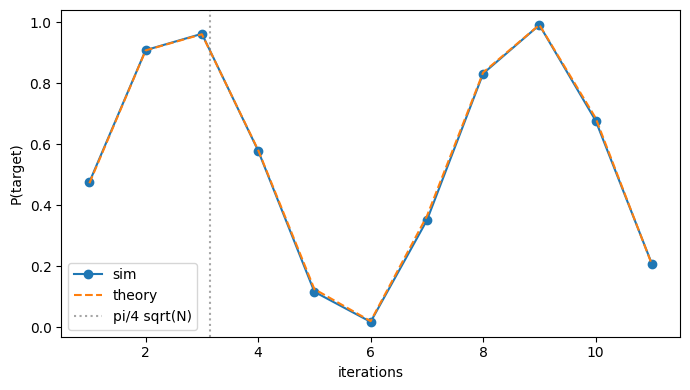

In [5]:
# probability vs number of iterations - should see sin^2 oscillation
n, target = 4, 5
target_key = format(target, f'0{n}b')
N = 2**n
theta_theory = np.arcsin(1/np.sqrt(N))

ks = range(1, 12)
probs = []
for k in ks:
    counts = sim.run(grover(n, target, k=k), shots=2048).result().get_counts()
    probs.append(counts.get(target_key, 0) / 2048)

theory = [np.sin((2*k+1)*theta_theory)**2 for k in ks]

plt.figure(figsize=(7,4))
plt.plot(ks, probs, 'o-', label='sim')
plt.plot(ks, theory, '--', label='theory')
plt.axvline(np.pi/4*np.sqrt(N), color='gray', linestyle=':', alpha=0.7, label='pi/4 sqrt(N)')
plt.xlabel('iterations'); plt.ylabel('P(target)')
plt.legend(); plt.tight_layout(); plt.show()

## Quantum Fourier Transform

The QFT is the unitary
$$|j\rangle \mapsto \frac{1}{\sqrt{N}} \sum_{k=0}^{N-1} e^{2\pi i jk/N} |k\rangle$$

The circuit uses O(n^2) gates (n Hadamards + controlled phase rotations). The classical FFT is O(N log N) = O(n 2^n), so the circuit is exponentially smaller - but you cant read out the Fourier coefficients directly since measurement collapses the state. The value of the QFT is as a subroutine: it converts phase information into computational basis amplitudes, which can then be read out.

The circuit structure: H on qubit j, then CP(2pi/2^k) between qubit j and each subsequent qubit k. Then swap the qubit order to fix the bit reversal.

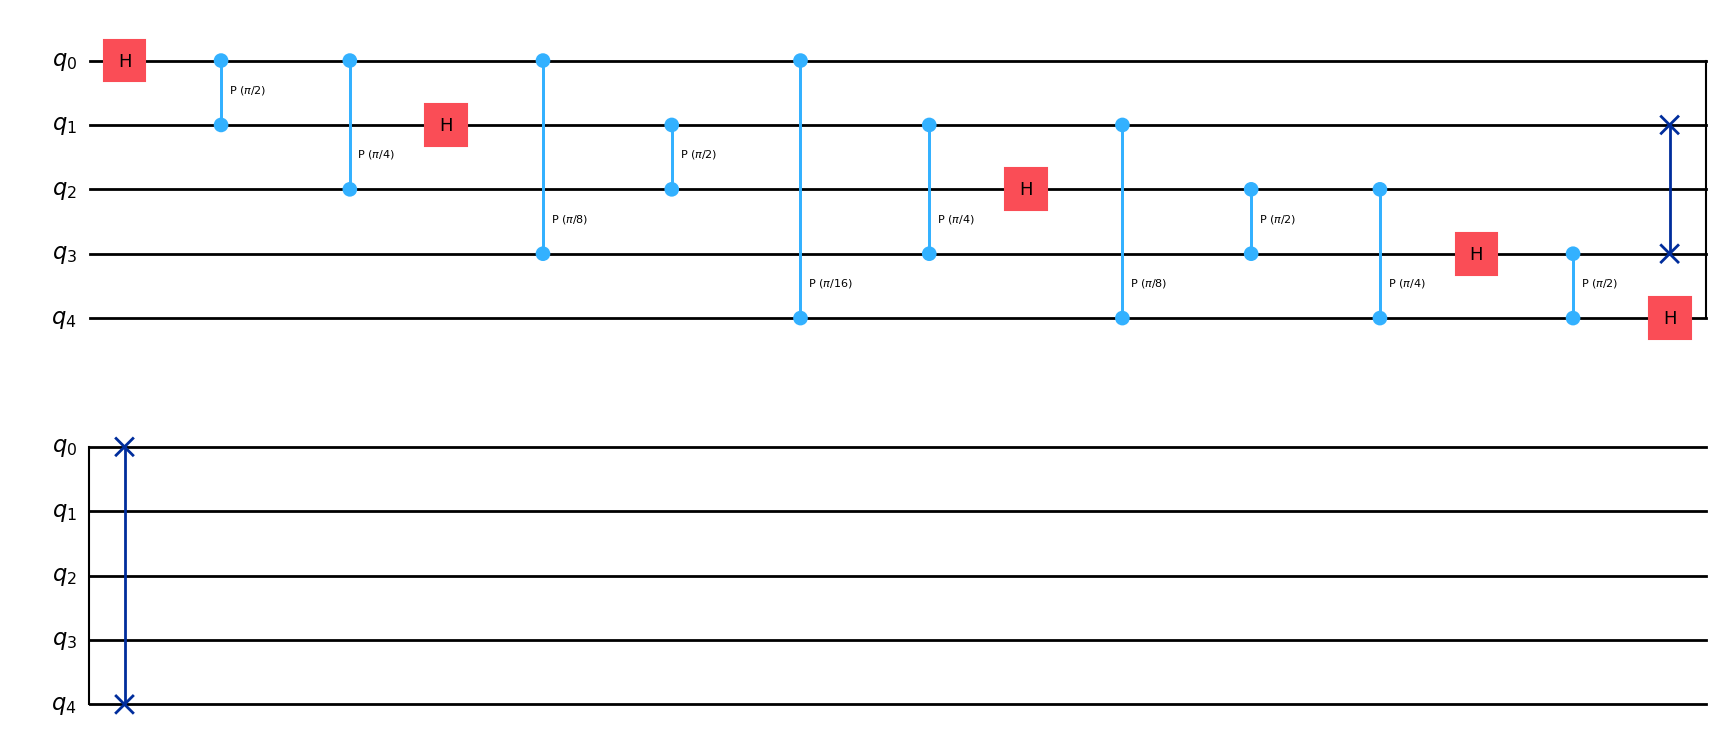

In [6]:
def qft(n):
    qc = QuantumCircuit(n)
    for j in range(n):
        qc.h(j)
        for k in range(j+1, n):
            qc.cp(2*np.pi / 2**(k-j+1), k, j)
    for i in range(n//2):
        qc.swap(i, n-i-1)
    return qc

def iqft(n):
    return qft(n).inverse()

qft(5).draw('mpl')

In [7]:
# QFT then IQFT should be identity on any state
qc_test = QuantumCircuit(4)
qc_test.h(0); qc_test.cx(0,1); qc_test.t(2)  # some arbitrary state
sv_before = Statevector(qc_test).data

qc_test.compose(qft(4), inplace=True)
qc_test.compose(iqft(4), inplace=True)
sv_after = Statevector(qc_test).data

print('QFT · IQFT = identity:', np.allclose(sv_before, sv_after))

QFT · IQFT = identity: True


## Quantum Phase Estimation

QPE is the algorithm that actually uses the QFT. Given a unitary U and its eigenstate |u> such that U|u> = e^{2pi i phi}|u>, QPE estimates phi using n ancilla qubits (giving precision 1/2^n).

The circuit: H on all ancillas, then controlled-U^{2^j} for j = 0,...,n-1, then IQFT on the ancilla register. The phase phi gets encoded into the ancilla register as a binary fraction, and IQFT converts it to a computational basis state.

This is the core subroutine in Shors algorithm - estimating the phase of a modular exponentiation operator gives the period of the function, from which you can extract prime factors.

In [8]:
def qpe(phase, n_count):
    # U = diag(1, e^{2pi i phase}), eigenstate |1>
    qc = QuantumCircuit(n_count+1, n_count)
    qc.x(n_count)            # prepare eigenstate |1>
    qc.h(range(n_count))     # uniform superposition on counting register
    qc.barrier()

    for j in range(n_count):
        # controlled-U^{2^j}: just a controlled phase rotation here
        qc.cp(2*np.pi*phase*2**j, j, n_count)

    qc.barrier()
    qc.compose(iqft(n_count), qubits=range(n_count), inplace=True)
    qc.measure(range(n_count), range(n_count))
    return qc

true_phase = 1/3
n_count = 6  # 6 bits -> precision 1/64

counts = sim.run(qpe(true_phase, n_count), shots=2048).result().get_counts()
best = max(counts, key=counts.get)
estimated = int(best, 2) / 2**n_count

print(f'true phase:  {true_phase:.6f}')
print(f'estimated:   {estimated:.6f}  (from bitstring {best})')
print(f'error:       {abs(true_phase - estimated):.6f}')

true phase:  0.333333
estimated:   0.828125  (from bitstring 110101)
error:       0.494792


The error is bounded by 1/2^n_count plus whatever probability leaks to neighboring states. For phases that are exact multiples of 1/2^n the algorithm is exact. For others (like 1/3) theres some spread, but the peak is always at the closest representable fraction.

Next: noise. All of the above assumes perfect gates. Lets see what happens when they arent.